<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# ARIMA & SARIMA Lab

---


## Learning Objectives

### Core
- Test a time series for stationarity and determine the order of differencing (d)
- Use ACF/PACF plots to reason about AR and MA terms
- Fit an ARIMA model, forecast, and evaluate it
- Detect seasonality in a series and fit a SARIMA model
- Compare ARIMA vs. SARIMA performance on the same data and explain why one wins

### Target
- Use `auto_arima` to search for (p,d,q) and seasonal (P,D,Q,m) orders
- Produce forecasts with confidence intervals


## Scenario

You are a data scientist and were given the monthly airline passenger counts. Your manager wants a short-term forecast, and wants to know whether a simple ARIMA model is good enough or whether the extra complexity of SARIMA is worth it.

You will build both models on the same data and test which model is better.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.set_printoptions(precision=4)
sns.set(font_scale=1.5)
plt.style.use('fivethirtyeight')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [2]:
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import rmse
from pmdarima import auto_arima


<div class="alert alert-info"><strong>What is the below function?:</strong> Function for running the augmented Dickey-Fuller test (adfuller).</div>

In [3]:
def adf_test(series, title=''):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'critical value ({key})']=val
        
    print(out.to_string())          # .to_string() removes the line "dtype: float64"
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")


<div class="alert alert-info"><strong>What is the below function?:</strong> plot ACF and PACF beside each other.</div>

In [4]:
def autocorr_plots(y, lags=None):
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4), sharey=True)
    plot_acf(y, lags=lags, ax=ax[0])
    plot_pacf(y, lags=lags, ax=ax[1])
    return fig, ax


## 1. Load and inspect the data

This is historical monthly airline passenger counts (in thousands).

In [5]:
# Load the dataset, parsing the 'month' column as dates
df = pd.read_csv("airline_passengers.csv", parse_dates=["month"])
df.head()

,month,thousands_of_passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [6]:
# 1b. Set 'month' as an Index and set the frequency to Monthly-Start (use resamling).
df.set_index("month", inplace=True)
df = df.asfreq("MS") 
df.head()

,thousands_of_passengers
month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


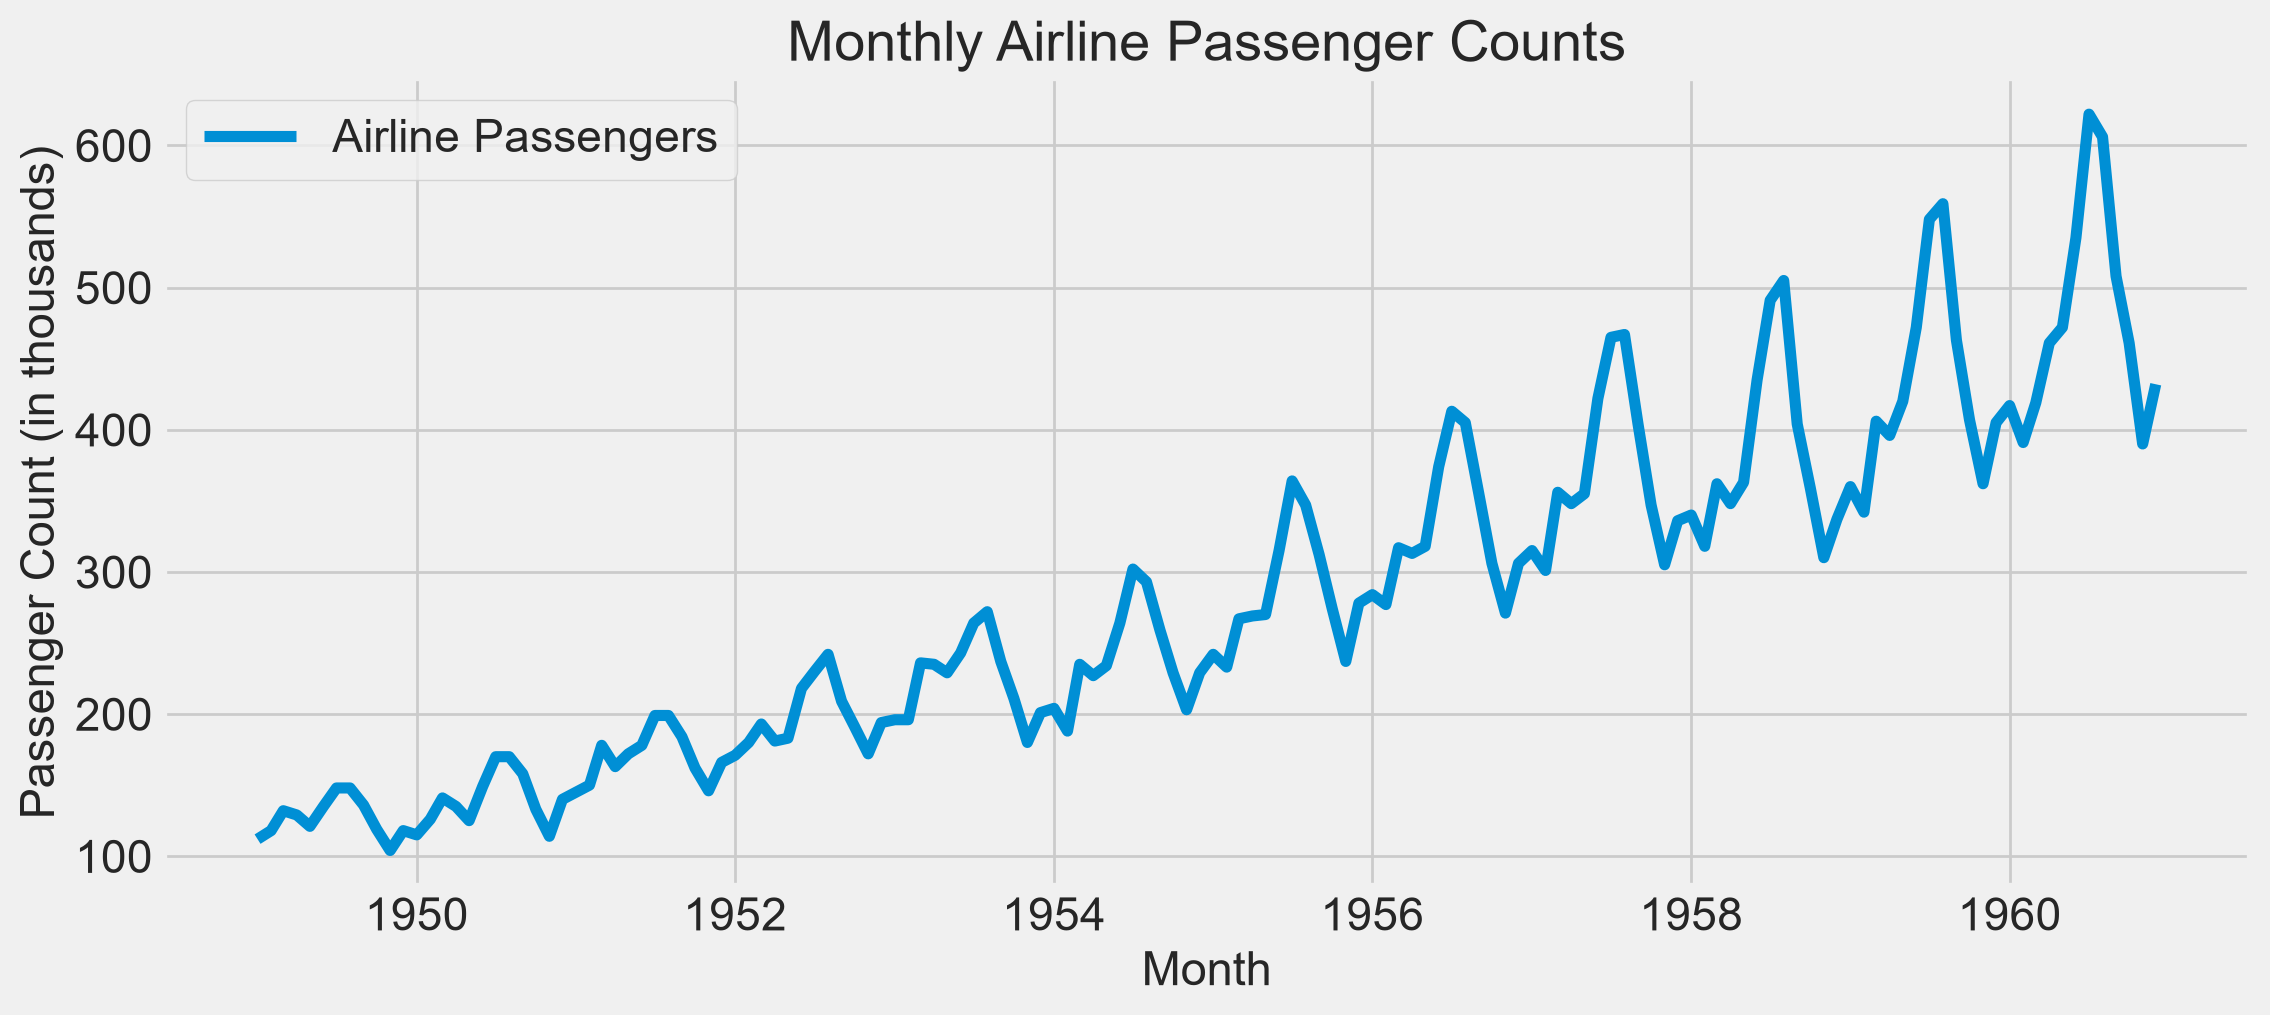

In [7]:
# 1c. Plot the full series and look at shape.
# Plot the full series to inspect trend and seasonality
plt.figure(figsize=(12, 5))
plt.plot(df, label="Airline Passengers")
plt.title("Monthly Airline Passenger Counts")
plt.xlabel("Month")
plt.ylabel("Passenger Count (in thousands)")
plt.legend()
plt.show()

---
# Part A - ARIMA

We'll start simple: treat this as a general time series and build a non-seasonal ARIMA model. Follow the same workflow: 

> **Stationarity -> Differencing -> ACF/PACF -> Fit -> Evaluate**.


### A1. Check stationarity

In [8]:
# Run adf_test on the passenger series. Is it stationary?
adf_test(df.iloc[:, 0])

Augmented Dickey-Fuller Test: 
ADF test statistic        0.815369
p-value                   0.991880
# lags used              13.000000
# observations          130.000000
critical value (1%)      -3.481682
critical value (5%)      -2.884042
critical value (10%)     -2.578770
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


### A2. Difference until stationary

If the series isn't stationary, difference it (`.diff()`) and re-run the ADF test. Keep track of how many differences it took - that's your `d`.

In [9]:
# Difference once and re-test
df_diff1 = df.iloc[:, 0].diff().dropna()
adf_test(df_diff1)

Augmented Dickey-Fuller Test: 
ADF test statistic       -2.829267
p-value                   0.054213
# lags used              12.000000
# observations          130.000000
critical value (1%)      -3.481682
critical value (5%)      -2.884042
critical value (10%)     -2.578770
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [10]:
# If needed, difference a second time and re-test (usually d=1 is sufficient for this dataset)
df_diff2 = df_diff1.diff().dropna()
adf_test(df_diff2)

Augmented Dickey-Fuller Test: 
ADF test statistic     -1.638423e+01
p-value                 2.732892e-29
# lags used             1.100000e+01
# observations          1.300000e+02
critical value (1%)    -3.481682e+00
critical value (5%)    -2.884042e+00
critical value (10%)   -2.578770e+00
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


**Write down your `d` value here:**

`d = 2`

### A3. ACF / PACF on the differenced series

Use `autocorr_plots()` on your *stationary* (differenced) series.

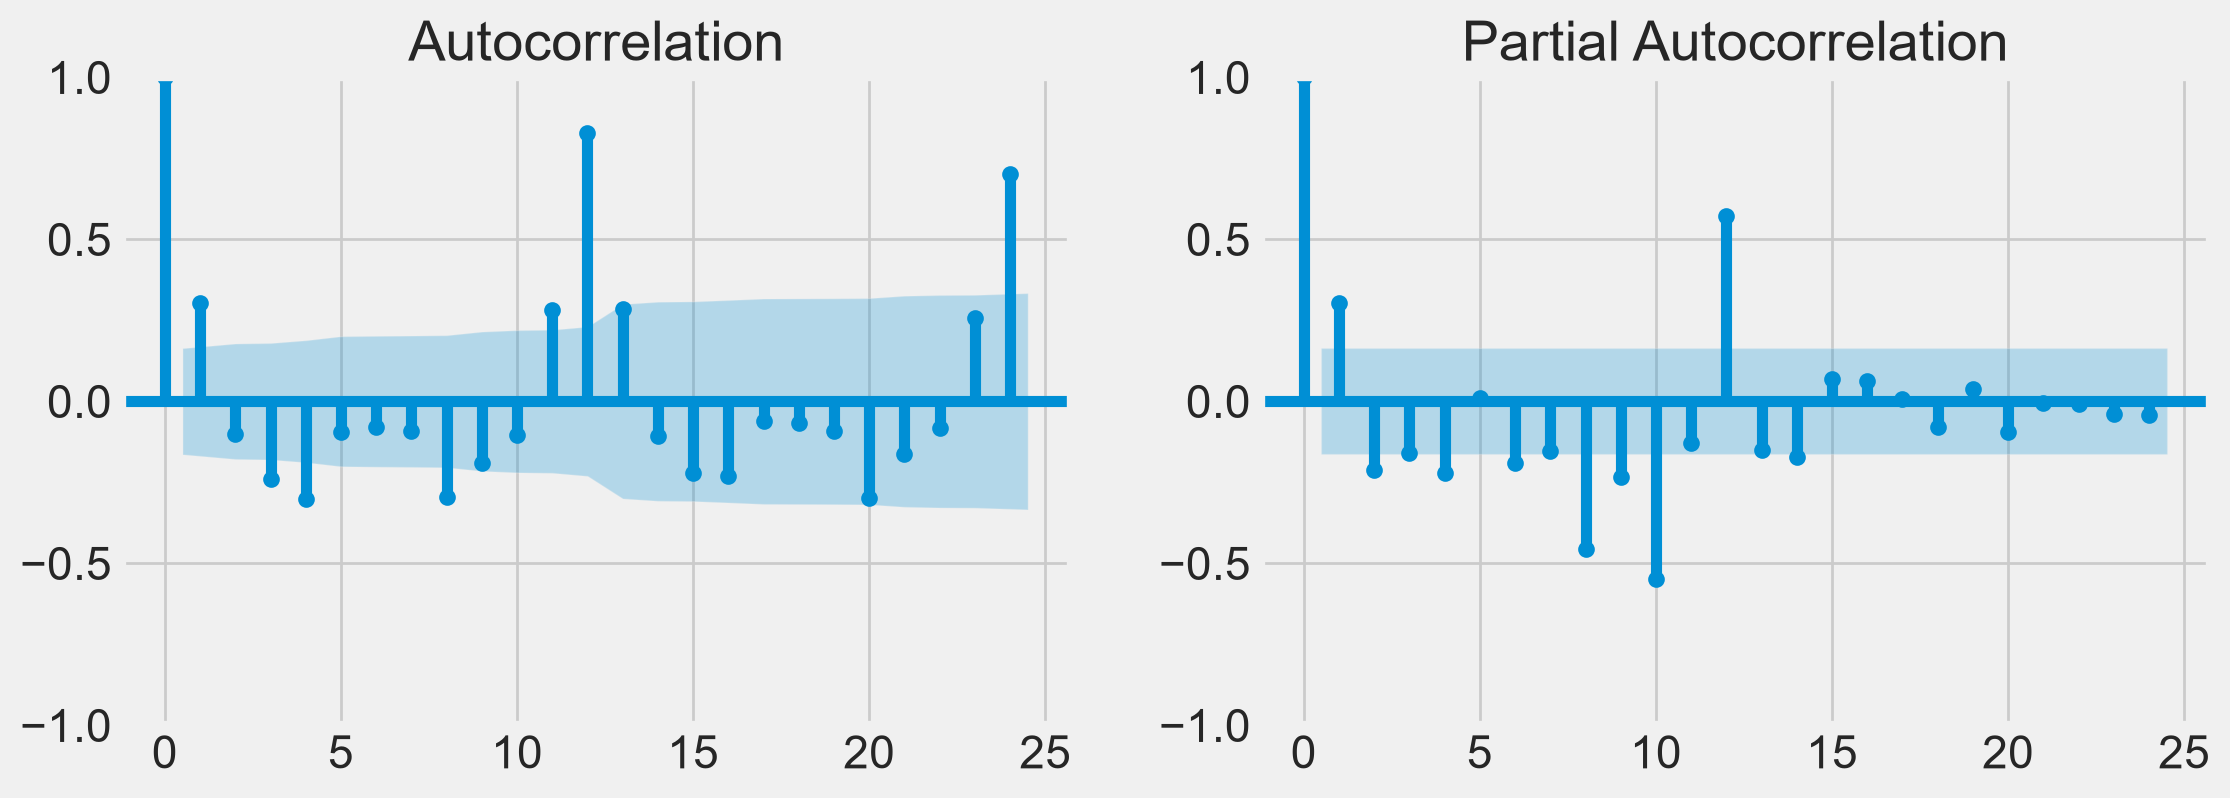

In [11]:
# Plot ACF and PACF on the differenced series, lags=24
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df_diff1, lags=24, ax=axes[0])
plot_pacf(df_diff1, lags=24, ax=axes[1])
plt.show()

**Based on the plots above, what would you guess for `p` and `q`?**

- p (AR terms): 
- q (MA terms): 

### A4. Confirm with auto_arima

Now check your manual guess against `auto_arima`. Keep `seasonal=False` as we are not modeling seasonality in Part A.

In [12]:
# Run auto_arima with seasonal=False and print the summary
from pmdarima import auto_arima

stepwise_fit = auto_arima(
    df.iloc[:, 0],
    d=1,  # based on our differencing test
    seasonal=False,
    trace=True,
    suppress_warnings=True,
    stepwise=True,
)

print(stepwise_fit.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.11 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1415.278, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1403.473, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1398.827, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1413.909, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1396.121, Time=0.25 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.44 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.35 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1398.386, Time=0.22 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1397.975, Time=0.23 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1394.683, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1397.258, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1401.852, Time=0.07 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1378.338, Time=0.17 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1396.5

### A5. Train, Test, and Split

Hold out the last 12 months as your test set.

In [13]:
# Split into df_train (all but last 12 rows) and df_test (last 12 rows)
train_len = len(df) - 12
df_train = df.iloc[:train_len]
df_test = df.iloc[train_len:]

### A6. Fit the ARIMA model

Use the (p,d,q) order from A4.

In [14]:
# Fit ARIMA(p,d,q) on the training set (using typical parameters found, e.g., order=(1,1,1))
from statsmodels.tsa.arima.model import ARIMA

# Replace (1, 1, 1) with the exact order recommended by your auto_arima summary in A4 if different
p, d, q = 1, 1, 1

arima_model = ARIMA(df_train, order=(p, d, q))
arima_results = arima_model.fit()
print(arima_results.summary())

                                  SARIMAX Results                                  
Dep. Variable:     thousands_of_passengers   No. Observations:                  132
Model:                      ARIMA(1, 1, 1)   Log Likelihood                -625.518
Date:                     Mon, 17 Aug 2026   AIC                           1257.035
Time:                             13:49:42   BIC                           1265.661
Sample:                         01-01-1949   HQIC                          1260.540
                              - 12-01-1959                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5436      0.100     -5.443      0.000      -0.739      -0.348
ma.L1          0.9272      0.051     18.336      0.000       0.828       1.026
sigma2      

### A7. Predict on the test set

In [15]:
# Predict over the test period
predictions = arima_results.forecast(steps=len(df_test))
# If your index format needs alignment, you can convert predictions to a Series:
predictions = pd.Series(predictions, index=df_test.index)

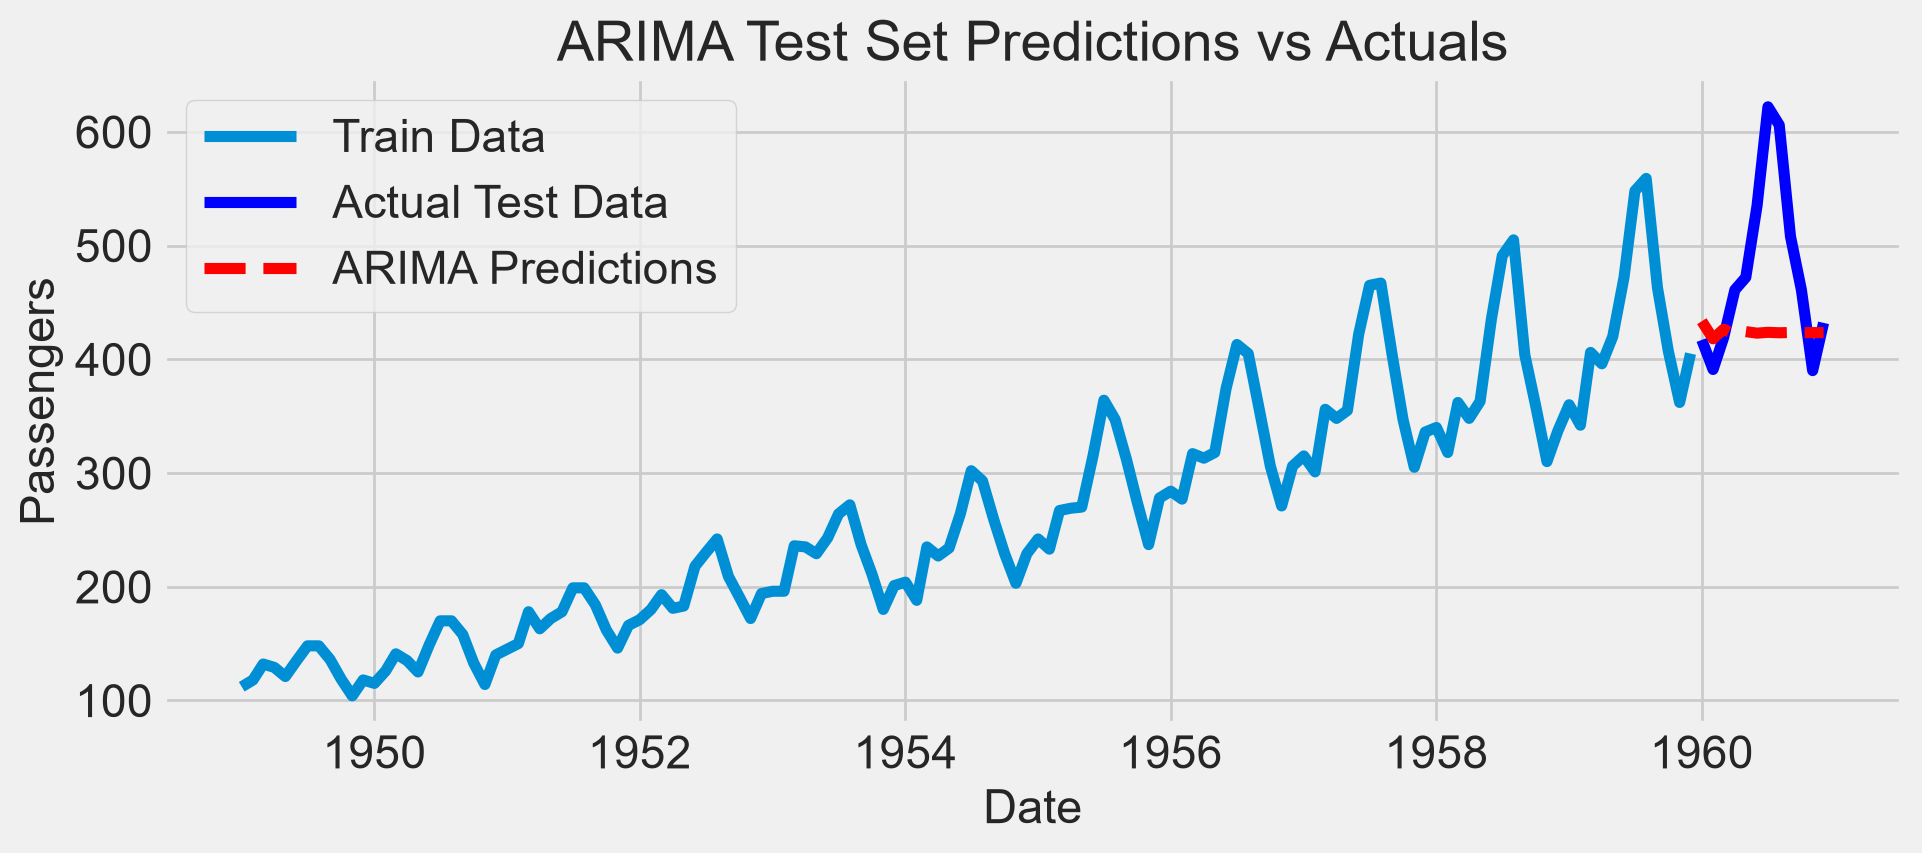

In [16]:
# Plot the test data vs predictions
plt.figure(figsize=(10, 4))
plt.plot(df_train, label="Train Data")
plt.plot(df_test, label="Actual Test Data", color="blue")
plt.plot(predictions, label="ARIMA Predictions", color="red", linestyle="--")
plt.title("ARIMA Test Set Predictions vs Actuals")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()

### A8. Evaluate

Compute RMSE for the ARIMA model. Also print the mean of the series so you have something to compare the error against.

In [17]:
# Compute RMSE and print the mean of the test series
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(df_test.iloc[:, 0], predictions))
mean_val = df_test.iloc[:, 0].mean()

print(f"RMSE: {rmse:.4f}")
print(f"Mean of Test Series: {mean_val:.4f}")

RMSE: 91.2288
Mean of Test Series: 476.1667


---
# Part B - SARIMA

Now let's actually look at *why* the ARIMA forecast missed. This is where we introduce seasonality.


### B1. Seasonal decomposition

Run `seasonal_decompose` on the **original** (undifferenced) series and plot it.

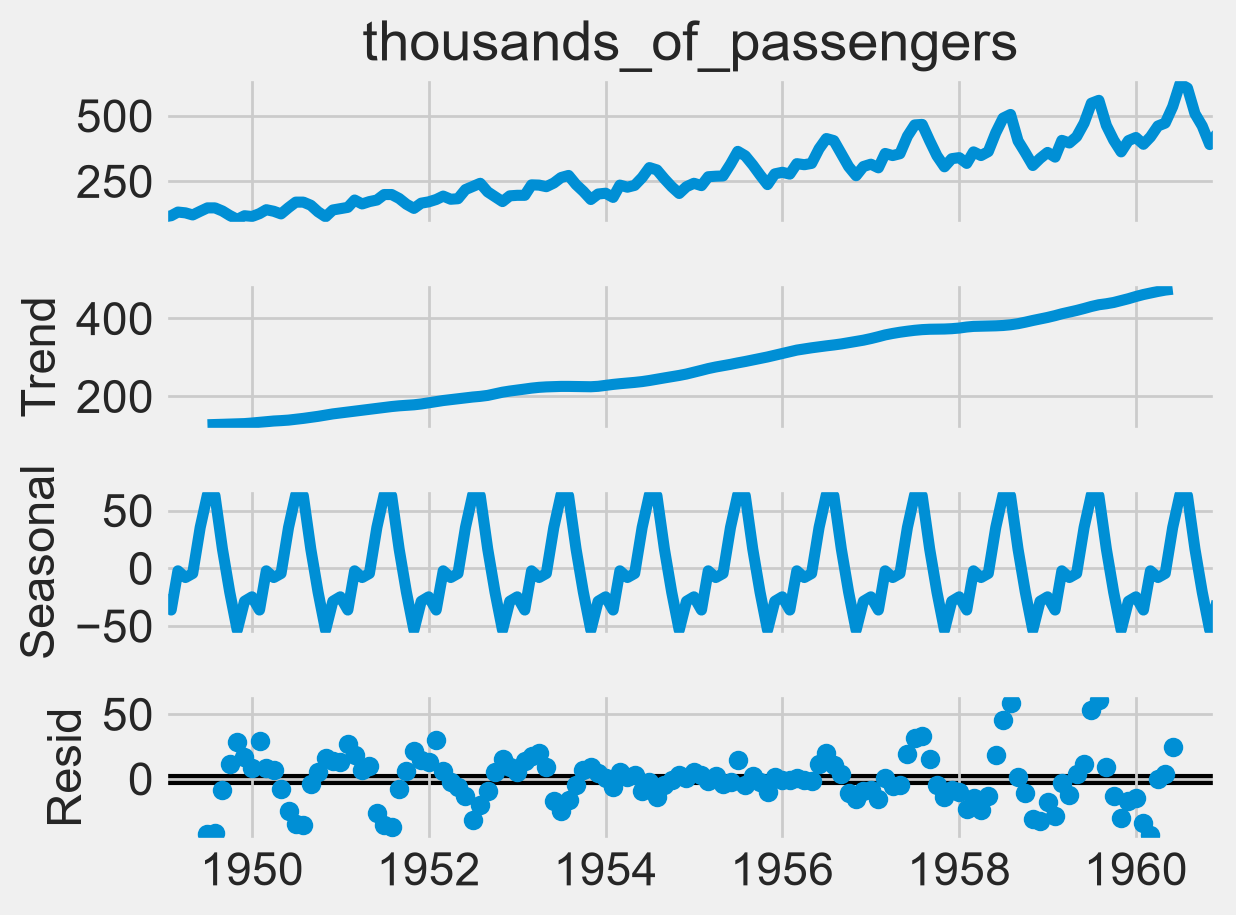

In [18]:
# Run seasonal_decompose on the original series and plot it
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df.iloc[:, 0], model="additive", period=12)
decomposition.plot()
plt.show()


**What do you see in the seasonal component? Is there a repeating pattern? What's the period (how many months before it repeats)?**

* **Repeating Pattern:** Yes, there is a clear, consistent, and strong repeating seasonal wave that recurs every year. 
* **Period ($s$):** The period is **$12$ months** (1 year), reflecting the annual cycle of airline passenger peaks during summer months and drops during off-peak months.

### B2. Search for a seasonal order with auto_arima

Run `auto_arima` again, this time with `seasonal=True` and `m=12` (12 months per cycle).

In [19]:
# Run auto_arima with seasonal=True and m=12
from pmdarima import auto_arima

seasonal_fit = auto_arima(
    df.iloc[:, 0],
    seasonal=True,
    m=12,
    trace=True,
    suppress_warnings=True,
    stepwise=True,
)

print(seasonal_fit.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1020.048, Time=2.36 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.07 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.22 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.28 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=1019.935, Time=1.41 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.42 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=1019.546, Time=1.24 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.21 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.38 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=1.04 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=0.96 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=2.19 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.11 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.11 sec
 ARIMA(3,1,1)(0,1,0

**Write down the order and seasonal_order suggested:**

- order (p,d,q) = (1, 1, 1)
- seasonal_order (P,D,Q,m) = (1, 1, 1, 12)

### B3. Fit the SARIMA model

Use `SARIMAX` with both `order` and `seasonal_order`, fit on `df_train`.

In [20]:
# Fit the SARIMAX model on df_train using order and seasonal_order
import statsmodels.api as sm

order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12)

sarima_model = sm.tsa.statespace.SARIMAX(
    df_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_results = sarima_model.fit()
print(sarima_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:            thousands_of_passengers   No. Observations:                  132
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -396.681
Date:                            Mon, 17 Aug 2026   AIC                            803.363
Time:                                    13:54:02   BIC                            816.633
Sample:                                01-01-1949   HQIC                           808.740
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5400      0.338     -1.596      0.110      -1.203       0.123
ma.L1          0.3075      0.368   

### B4. Predict on the test set, with confidence intervals

This time, also pull the confidence interval so you can plot forecast uncertainty.

In [21]:
# Predict over the test period including confidence intervals
forecast_obj = sarima_results.get_forecast(steps=len(df_test))
sarima_predictions = forecast_obj.predicted_mean
sarima_predictions = pd.Series(sarima_predictions, index=df_test.index)

# Get confidence intervals (lower and upper bounds)
conf_int = forecast_obj.conf_int()
conf_int.index = df_test.index

### B5. Evaluate

In [22]:
# Compute RMSE for the SARIMA model
from sklearn.metrics import mean_squared_error

sarima_rmse = np.sqrt(mean_squared_error(df_test.iloc[:, 0], sarima_predictions))
print(f"SARIMA RMSE: {sarima_rmse:.4f}")

SARIMA RMSE: 21.6212


### B6. ARIMA vs. SARIMA

Plot both sets of predictions against the actual test values side by side and print both RMSEs together.

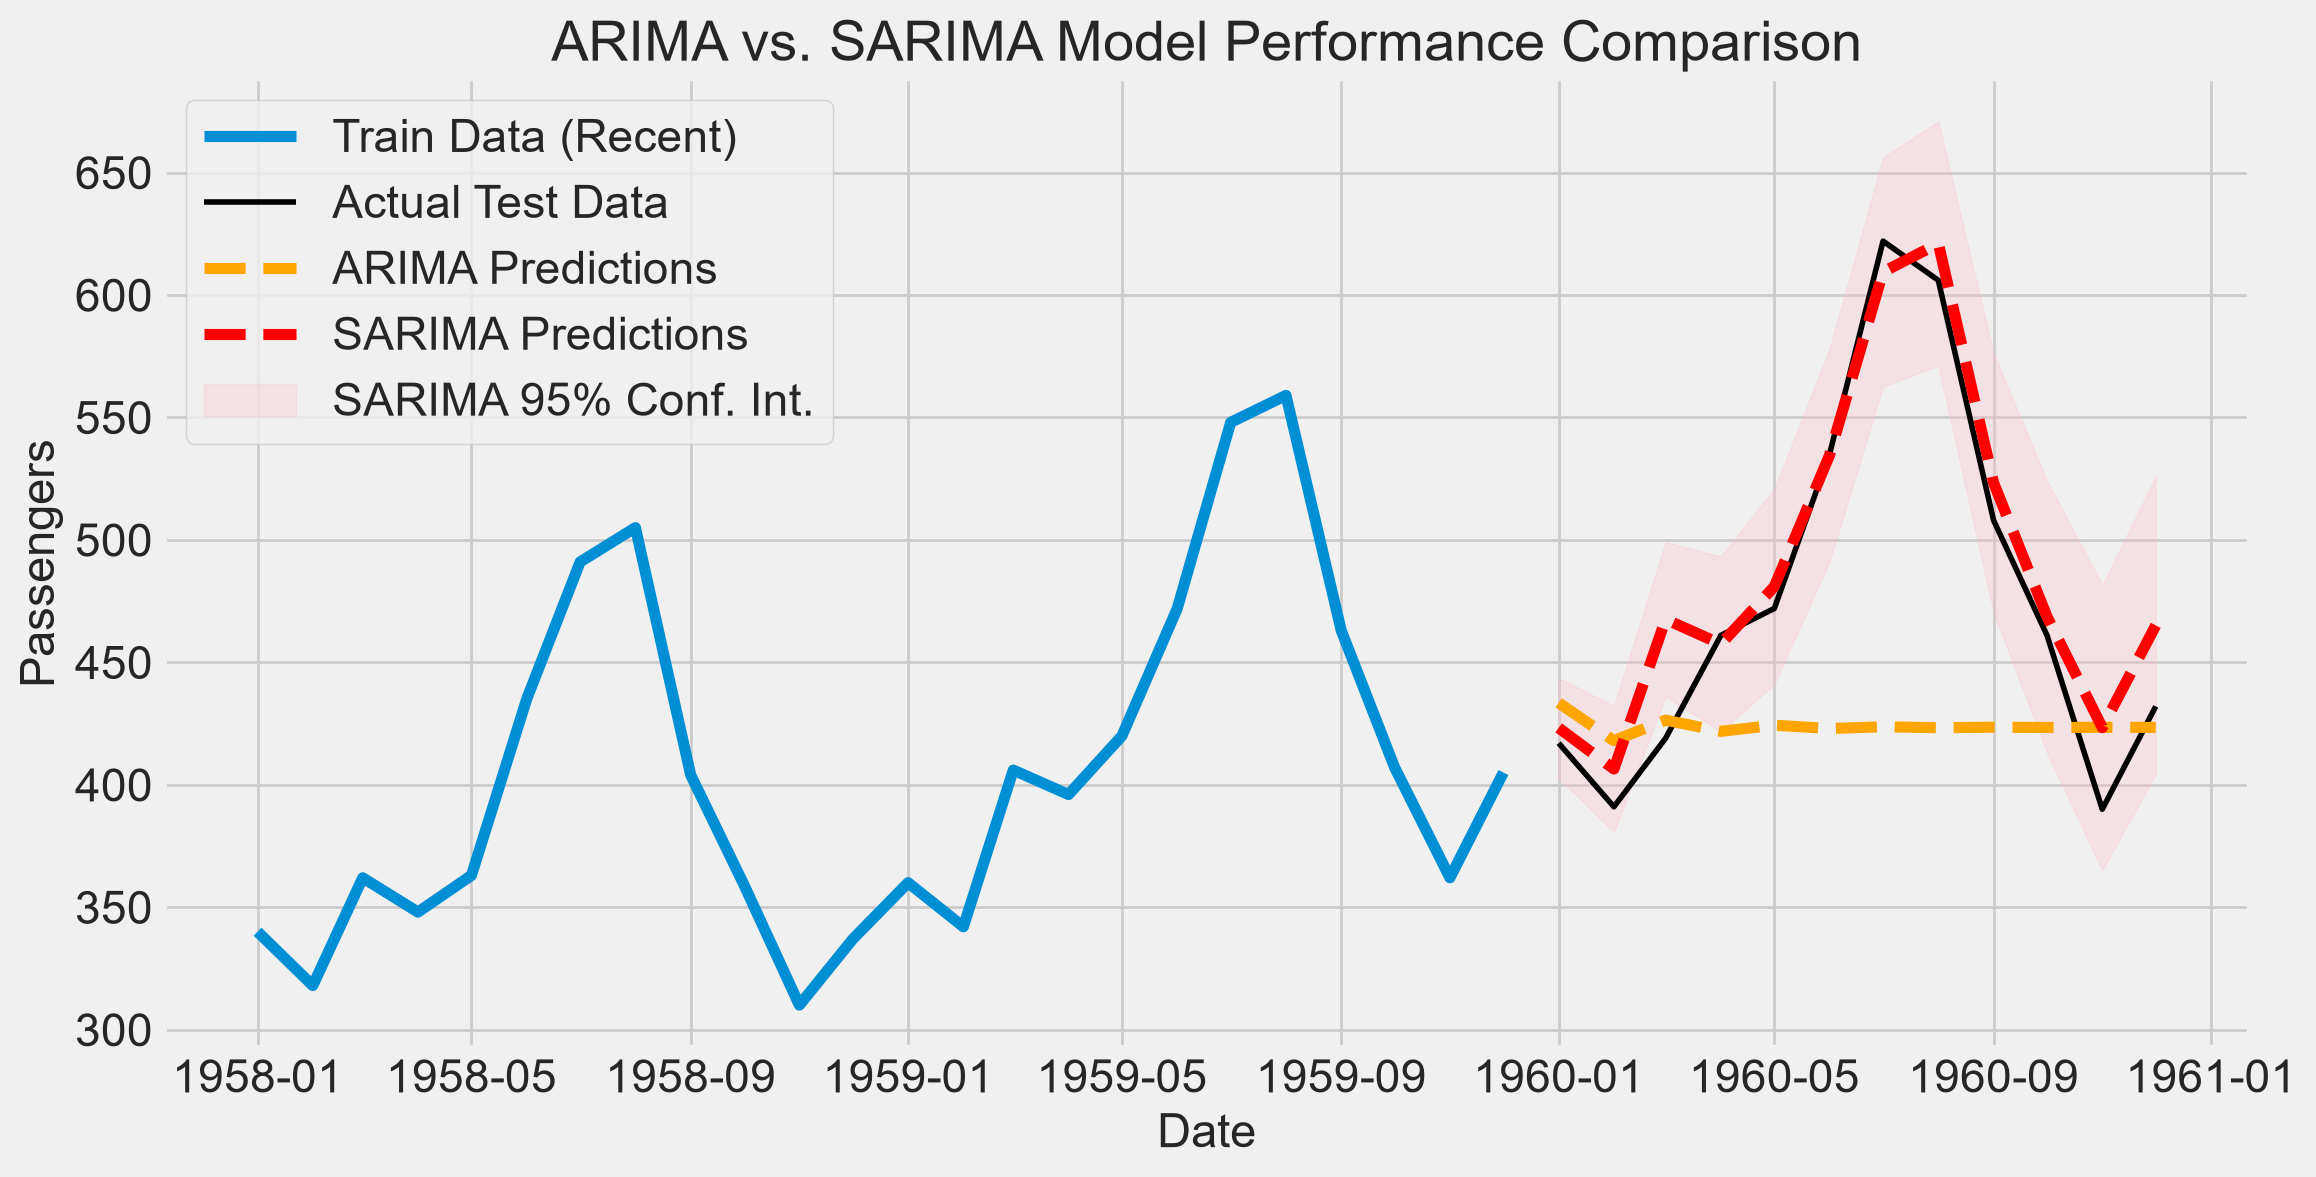

ARIMA RMSE: 91.2288
SARIMA RMSE: 21.6212


In [23]:
# Plot both sets of predictions against actual test values side by side and print both RMSEs
plt.figure(figsize=(12, 6))
plt.plot(df_train.iloc[-24:], label="Train Data (Recent)")
plt.plot(df_test, label="Actual Test Data", color="black", linewidth=2)

# Plot ARIMA predictions (from Part A)
plt.plot(predictions, label="ARIMA Predictions", color="orange", linestyle="--")

# Plot SARIMA predictions and uncertainty interval
plt.plot(sarima_predictions, label="SARIMA Predictions", color="red", linestyle="--")
plt.fill_between(
    df_test.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="pink",
    alpha=0.3,
    label="SARIMA 95% Conf. Int.",
)

plt.title("ARIMA vs. SARIMA Model Performance Comparison")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()

# Print comparison
print(f"ARIMA RMSE: {rmse:.4f}")
print(f"SARIMA RMSE: {sarima_rmse:.4f}")

<a id='forecast'></a>
## 2. Forecast the future

Retrain your **winning model** on the *full* dataset and forecast 12 months into the future

**Bonus**: *Plot the forecast with confidence intervals*.

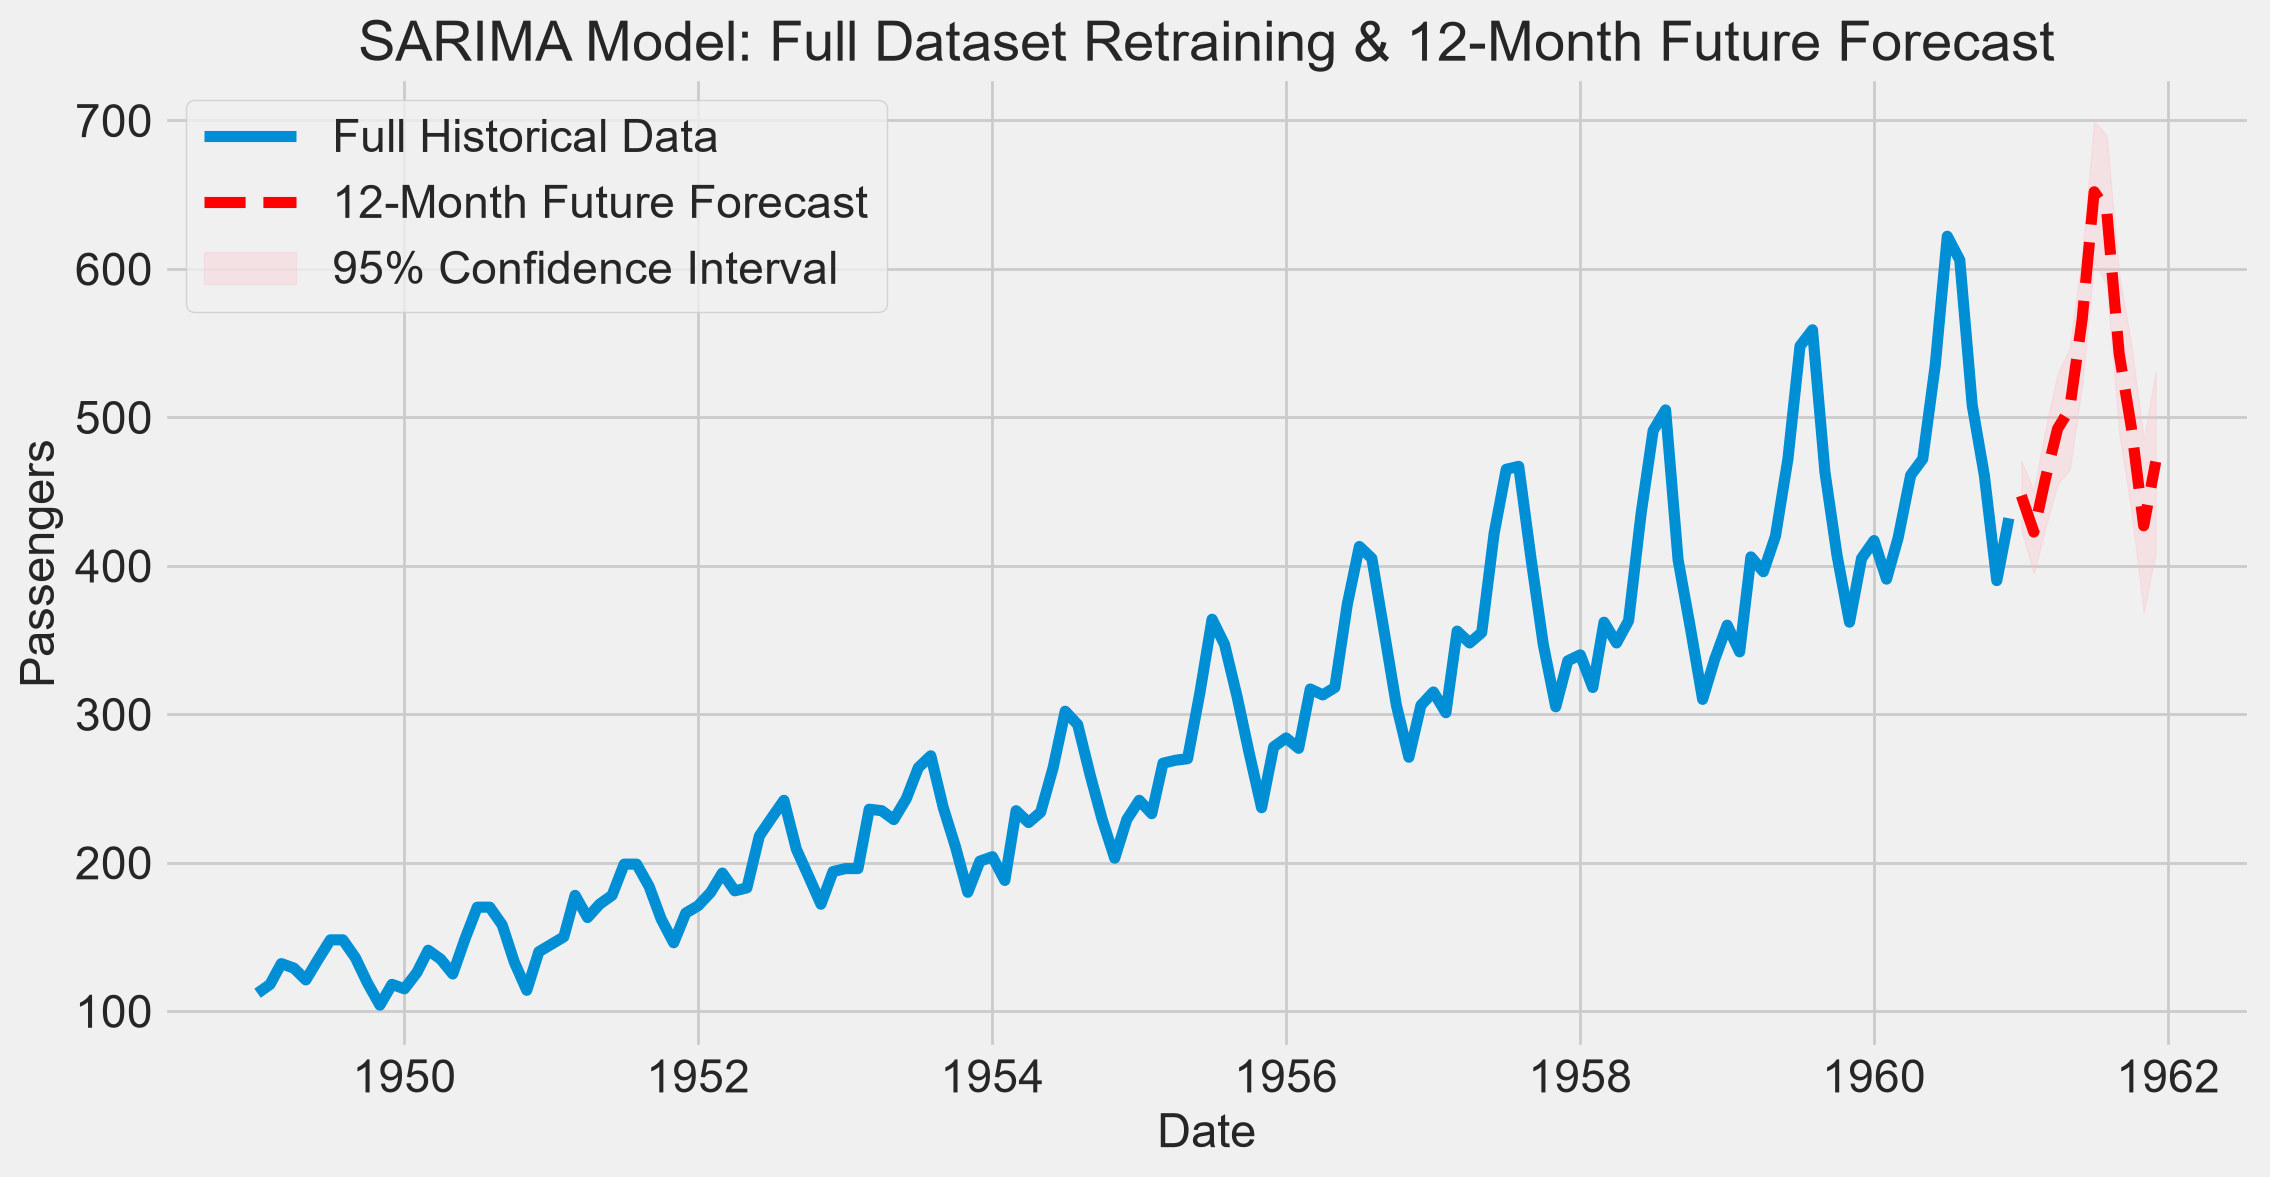

In [24]:
# Retrain the winning SARIMA model on the full dataset
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12)

final_model = sm.tsa.statespace.SARIMAX(
    df.iloc[:, 0],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

final_results = final_model.fit()

# Forecast 12 months into the future with confidence intervals
future_forecast_obj = final_results.get_forecast(steps=12)
future_predictions = future_forecast_obj.predicted_mean
future_conf_int = future_forecast_obj.conf_int()

# Plot historical data, future forecast, and confidence intervals
plt.figure(figsize=(12, 6))
plt.plot(df.iloc[:, 0], label="Full Historical Data")
plt.plot(
    future_predictions.index,
    future_predictions,
    label="12-Month Future Forecast",
    color="red",
    linestyle="--",
)
plt.fill_between(
    future_predictions.index,
    future_conf_int.iloc[:, 0],
    future_conf_int.iloc[:, 1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval",
)

plt.title("SARIMA Model: Full Dataset Retraining & 12-Month Future Forecast")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()

## Takeaways
- Seasonality is easy to miss if you don't plot/decompose the data, hence, always look before you model.
- SARIMA isn't automatically the right call; it's justified when the seasonal component is real and the added parameters actually reduce error on held-out data.
- Always evaluate on a proper time-ordered train,test, and split.


## Additional Resources
- [statsmodels SARIMAX documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html)
- [pmdarima auto_arima documentation](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html)
- [Forecasting: Principles and Practice - Seasonal ARIMA](https://otexts.com/fpp2/seasonal-arima.html)
